## Introduction

The goal of this project is to develop a model that classifies types of supernovae based on their light curves, specifically focusing on photometric data. The task at hand is to distinguish between two primary types of supernovae: Type I (SN I) and Type II (SN II) through binary classification.

This study draws inspiration from a research paper which explores advanced preprocessing methods for constructing light curves using Gaussian processes. The paper, which can be accessed [here](https://arxiv.org/abs/2105.06178), details the use of Gaussian processes to smooth and interpolate the raw photometric data, thereby facilitating better feature extraction for subsequent classification tasks.

The model we intend to build, referred to as "T2", is based on the transformer architecture.In this project, we leverage the transformer model to process the time-series data derived from the light curves of supernovae, aiming to efficiently classify these astronomical events into their respective types.

## Setup

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

import importlib
import src.preprocessing.tools as tools
import src.preprocessing.load_csv as load_csv
import src.preprocessing.plot_data as plot_data
import src.preprocessing.data_augmentation as data_augmentation
import src.evaluation.plot_evaluation as plot_evaluation

importlib.reload(plot_evaluation)
importlib.reload(data_augmentation)
importlib.reload(load_csv)
importlib.reload(plot_data)
importlib.reload(tools)

from src.preprocessing.load_csv import load_BTS_data, load_all_photometry
from src.preprocessing.plot_data import plot_types_distributions, plot_photometry, plot_gp
from src.preprocessing.tools import categorize_type, Mag2Flux, Normalize_mjd, count_obj_by_type, robust_scale
from src.preprocessing.data_augmentation import augment_data_with_noise, balanced_augmentation
from src.evaluation.plot_evaluation import plot_history, plot_multi_class_roc, plot_confusion_matrix, plot_class_accuracy, early_classification_tradeoff

## Data Selection

In [ ]:
df = load_BTS_data('data/BTS.csv')
df.head()

,objectId,IAUID,RA,Dec,peakt,peakfilt,peakmag,peakabs,duration,rise,fade,type,redshift,b,A_V
0,ZTF17aaaeqms,AT2023jkf,01:19:13.43,+31:46:26.1,2102.97,r,17.5839,-,18.001,12.004,5.997,-,-,-30.726791,0.205
1,ZTF17aaajowi,-,11:47:44.37,+14:34:10.4,1362.73,r,18.9963,-,>5.611,2.651,>2.96,-,-,70.564727,0.127
2,ZTF17aaanztg,AT2021abaw,10:04:06.59,-01:12:18.6,1501.02,r,18.3035,-,>14.737,>3,11.737,-,-,40.798120,0.210
3,ZTF17aaaocnx,AT2019dlf,06:12:54.20,+48:49:57.0,584.70,g,17.2290,-,6.213,0.803,5.41,-,-,14.194943,0.407
4,ZTF17aaaptxx,AT2023gdf,11:54:24.96,+09:36:32.8,2053.73,g,18.9437,-,>2,>2,>0,-,-,67.910221,0.079


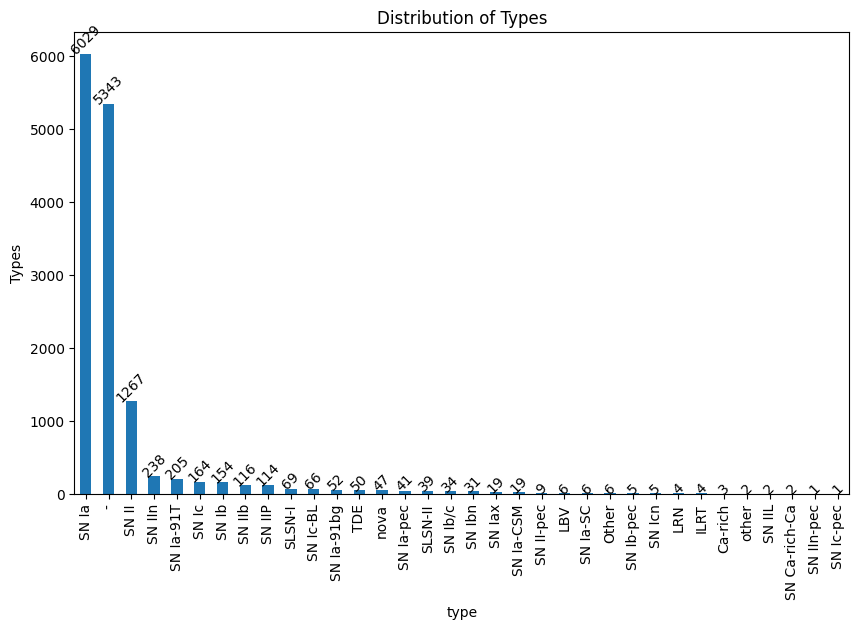

In [ ]:
plot_types_distributions(df)

### Project Overview

The main objective of this project is to explore and test various feature extraction methods for photometric data on supernovae.

### Data Categorization

For the purpose of this analysis, I have chosen to categorize the supernovae into three distinct groups:
- **Type I Supernovae (SN I)**: This category includes all Type I supernovae.
- **Type II Supernovae (SN II)**: This group encompasses all Type II supernovae.
- **Other**: Any supernovae that do not fit into the above two categories will be classified under 'Other'.

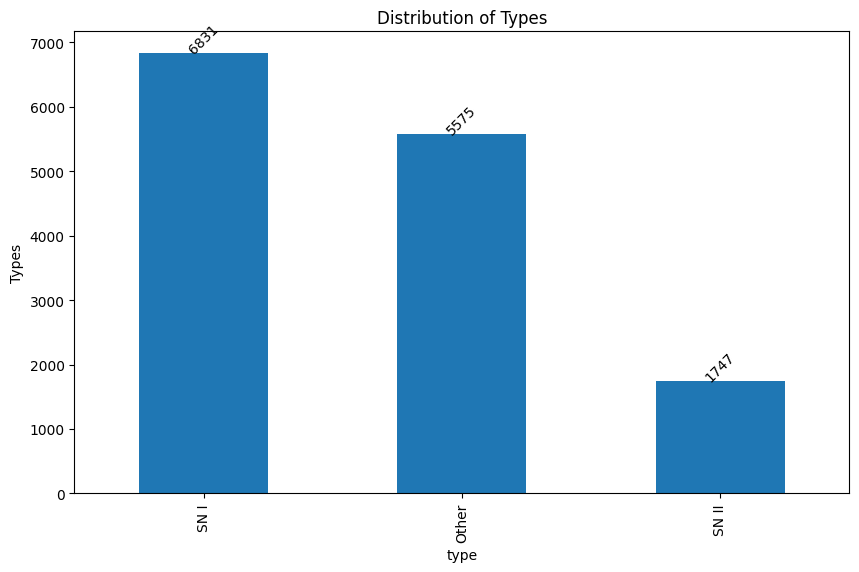

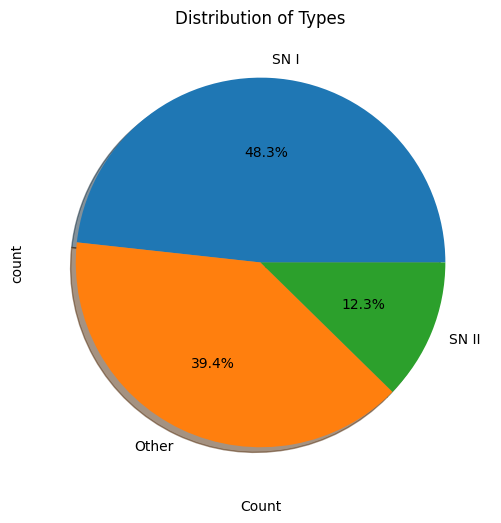

In [ ]:
df['type'] = df['type'].apply(categorize_type)
plot_types_distributions(df)
plot_types_distributions(df, form='pie')

In [ ]:
# DATA_DIRECTORY = "/media/theob/E/ML_project_data/data"
# photo_df = load_all_photometry(df, DATA_DIRECTORY, save=True)

photo_df = pd.read_csv('data/photometry_Other_SN_I_SN_II.csv')
photo_df = photo_df[photo_df['filter'].isin(['ztfg', 'ztfr', 'ztfi'])]
photo_df.dropna(inplace=True)
photo_df.reset_index(drop=True, inplace=True)
photo_df.head()

,obj_id,mjd,mag,magerr,snr,limiting_mag,filter,type
0,ZTF17aaaeqms,60087.478935,18.860077,0.162338,6.688104,19.175910,ztfr,Other
1,ZTF17aaaeqms,60087.478935,18.860100,0.162338,6.688121,19.175935,ztfr,Other
2,ZTF17aaaeqms,60088.476968,18.333413,0.092138,11.783856,19.264206,ztfr,Other
3,ZTF17aaaeqms,60088.476968,18.333401,0.092138,11.783805,19.264190,ztfr,Other
4,ZTF17aaaeqms,60088.479340,18.568918,0.100185,10.837333,19.408799,ztfr,Other


### Data Augmentation Function Explanation

The function `augment_data_with_noise` is designed to enhance the robustness of our machine learning models by creating augmented versions of the original dataset. This data augmentation process involves manipulating the photometric data of each observed supernova object in the following manner:

1. **Subset Creation**: For each unique object in the dataset, we create three subsets containing 80%, 50%, and 20% of the original data points, based on the measurement dates (`mjd`). This step simulates scenarios where only a portion of the data is available, mimicking real-world observational limitations.

2. **Noise Addition**: To each of these subsets, we add Gaussian noise to the photometric measurements (`mag` for magnitude and `magerr` for magnitude error). The noise is scaled by a specified `noise_level` parameter and is calculated as a fraction of the standard deviation of the data in the flux columns. This step is intended to test the model's ability to handle observational noise and variability in data quality.

3. **Data Integration**: The augmented data entries, which now represent the original object under different observational conditions and noise levels, are then labeled with a unique identifier and combined back into the main dataset.


In [ ]:
# photo_df = augment_data_with_noise(photo_df, noise_level=0.05)
# photo_df.to_csv('augmented_SNI_SNII_Other_photometry.csv', index=False)

photo_df = pd.read_csv('data/augmented_SNI_SNII_Other_photometry.csv')

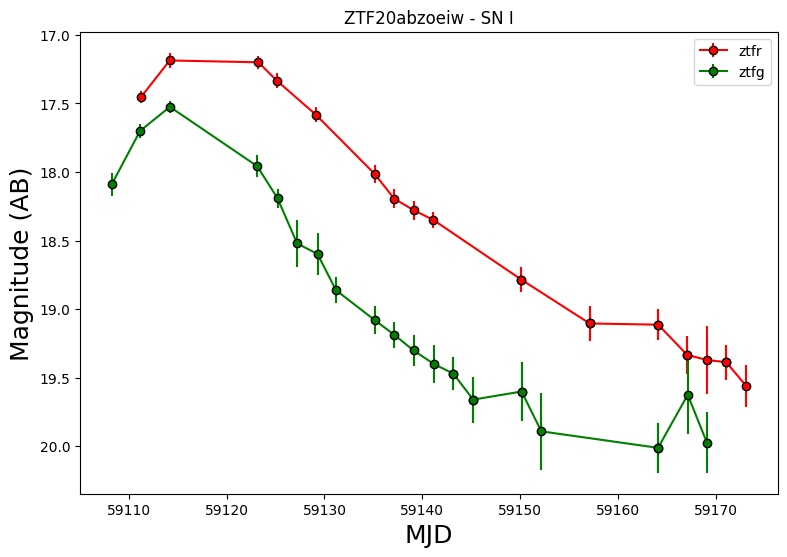

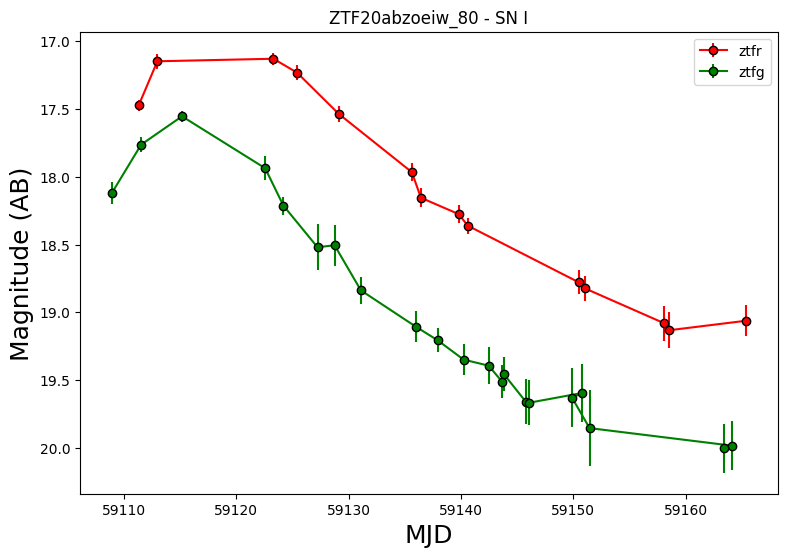

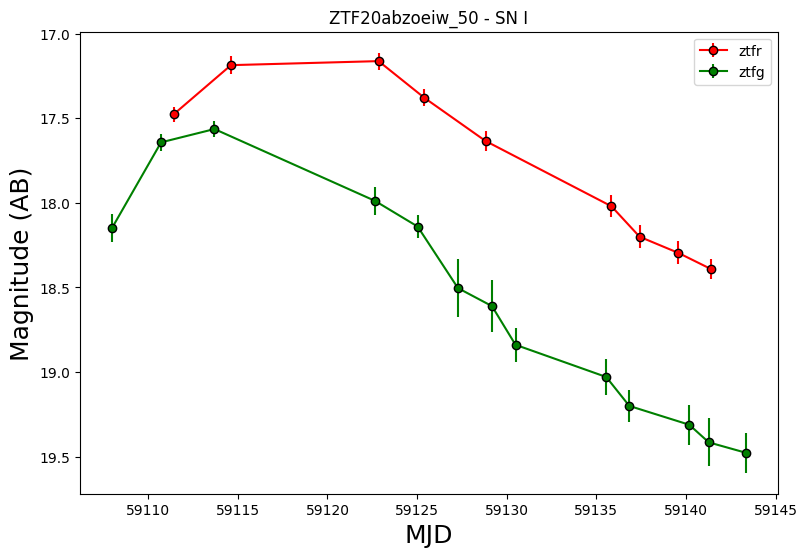

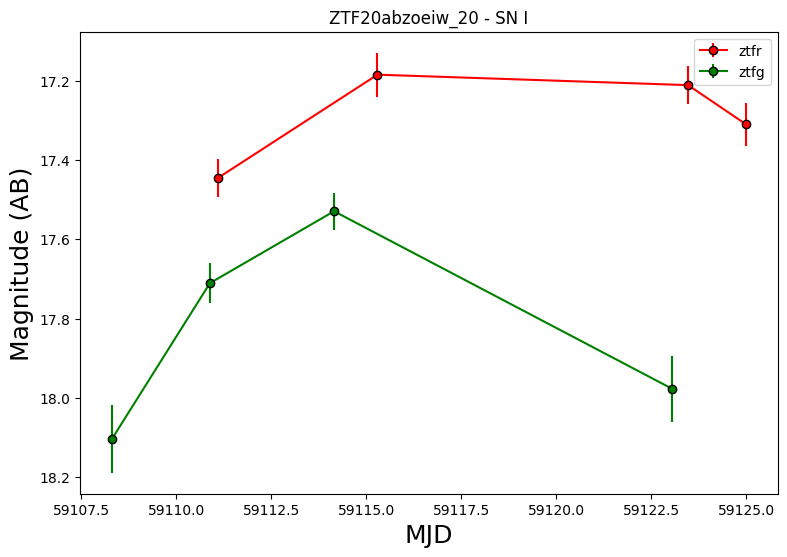

In [ ]:
# Set a base ID for filtering
id_base = 'ZTF20abzoeiw'  # Hard-coded example ID

# Collect all IDs from the DataFrame that start with the base ID
relevant_ids = [obj_id for obj_id in photo_df['obj_id'].unique() if obj_id.startswith(id_base)]

# Iterate through each relevant ID, retrieve the corresponding data, and plot the photometry
for i, obj_id in enumerate(relevant_ids):
    one_df = photo_df[photo_df['obj_id'] == obj_id]  # Get the DataFrame for the current object ID
    plot_photometry(one_df)  # Call a function to plot photometry data for this DataFrame


### Conversion of Magnitude to Flux

To analyze the photometric data effectively using Gaussian processes, we first convert the observed magnitudes into flux measurements. The conversion from magnitude (`mag`) to flux (`flux`) is based on the following formula:

$$
\text{flux} = 10^{-0.4 \times (\text{mag} - 23.9)}
$$

Additionally, we calculate the flux error (`flux_error`) using the associated magnitude error (`magerr`), with the conversion given by:

$$
\text{flux\_error} = \left( \frac{\text{magerr}}{2.5 / \ln(10)} \right) \times \text{flux}
$$

This formula adjusts the magnitude error to be proportional to the flux based on the logarithmic relationship between flux and magnitude.

### Normalization of Modified Julian Date (MJD)

The temporal information for each object, given by the Modified Julian Date (MJD), is normalized so that each object's observational timeline starts at zero.

In [ ]:
photo_df = Mag2Flux(photo_df)
photo_df = Normalize_mjd(photo_df)
photo_df.head()

,obj_id,mjd,flux,flux_error,filter,type
0,ZTF17aaaeqms,0.000000,103.745445,15.511937,ztfr,Other
1,ZTF17aaaeqms,0.000000,103.743279,15.511573,ztfr,Other
2,ZTF17aaaeqms,0.998032,168.513611,14.300379,ztfr,Other
3,ZTF17aaaeqms,0.998032,168.515366,14.300590,ztfr,Other
4,ZTF17aaaeqms,1.000405,135.654022,12.517288,ztfr,Other


In [ ]:
count_obj_by_type(photo_df)

type
Other    21783
SN I     27201
SN II     6971
Name: obj_id, dtype: int64


### Data Filtering Criteria

We only retain objects in our dataset that meet the following conditions for reliable analysis:
- Each object must have **at least three observations**.
- These observations must be across **at least two different filters**.

This filtering ensures the dataset includes only those objects with sufficient data spread across multiple spectral bands, essential for robust analysis.

In [ ]:
filtered_df = photo_df.groupby('obj_id').filter(lambda x: x.groupby('filter')['mjd'].count().ge(3).sum() >= 2)
filtered_df.reset_index(drop=True, inplace=True)
count_obj_by_type(filtered_df)

type
Other    13453
SN I     21960
SN II     6018
Name: obj_id, dtype: int64


In [ ]:
filtered_df = pd.read_csv('data/filtered_SNI_SNII_Other_photometry.csv')

### Data Interpolation with Gaussian Processes

We employ Gaussian Process (GP) regression to preprocess our photometric data, leveraging the method's capacity to handle irregular sampling and heteroskedastic errors. This approach, inspired by *Paying Attention to Astronomical Transients*, is especially useful for modeling supernova light curves which often have sparse and irregular observations.

#### Key Implementation:
- **Kernel Choice**: We use a 2-dimensional Matern kernel, adapted from Boone (2019), to account for both time and wavelength, enhancing predictions across different passbands.
- **Application**: The GP is trained on subsets of original data and then used to predict light curves at regular intervals, thus standardizing the time-series data for further analysis.


![](assets/gp_explain.png)

In [ ]:
# Create a DataFrame 'mini_data' that excludes any objects with IDs containing '_xx' where 'xx' are numbers. This helps isolate original objects without derived versions.
mini_data = filtered_df[~filtered_df['obj_id'].str.contains('_')]
count_obj_by_type(mini_data)

type
Other    4345
SN I     6401
SN II    1647
Name: obj_id, dtype: int64


In [199]:
# Uncomment the below lines to fit a 2D Gaussian Process on 'mini_data' and use the resulting kernel for processing the 'filtered_df'.
# kernel, _ = fit_2d_gp(mini_data, kernel=None, return_kernel=True)
# all_gp = process_gaussian(filtered_df, kernel=kernel, name='all', save=True)

# Load the preprocessed Gaussian Process results from a CSV file into the DataFrame 'all_gp'.
all_gp = pd.read_csv('data/all_gp_Other_SN_I_SN_II.csv')

# Display the first few rows of the DataFrame 'all_gp' to show the results of the Gaussian Process.
all_gp[all_gp['obj_id'] == 'ZTF23abieafn'].head()

,mjd,flux_ztfg,flux_ztfr,flux_error_ztfg,flux_error_ztfr,type,obj_id,flux_ztfi,flux_error_ztfi
1159000,0.000000,64.952496,56.849150,18.529798,10.157785,SN I,ZTF23abieafn,34.747763,38.919406
1159001,0.756231,72.465758,65.574755,16.264358,9.008675,SN I,ZTF23abieafn,40.310674,38.017851
1159002,1.512462,80.154483,74.590389,14.007584,8.067161,SN I,ZTF23abieafn,45.890645,37.164973
1159003,2.268693,87.997732,83.779781,11.768090,7.198560,SN I,ZTF23abieafn,51.453181,36.353054
1159004,3.024924,95.973522,93.024349,9.561761,6.294066,SN I,ZTF23abieafn,56.962241,35.573912


### Data Scaling with RobustScaler

We apply `RobustScaler` from scikit-learn to columns specified in the `robust_scale` function. This scaler removes the median and scales the data according to the quantile range, making it robust against outliers.

In [200]:
scale_columns = ['flux_ztfg', 'flux_ztfr', 'flux_ztfi', 'flux_error_ztfg', 'flux_error_ztfr', 'flux_error_ztfi']
all_gp = robust_scale(all_gp, scale_columns)
all_gp[all_gp['obj_id'] == 'ZTF23abieafn'].head()

/home/theob/anaconda3/envs/ml_skyportal_env/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


,mjd,flux_ztfg,flux_ztfr,flux_error_ztfg,flux_error_ztfr,type,obj_id,flux_ztfi,flux_error_ztfi
1159000,0.000000,-0.258734,-0.495969,1.198247,0.454021,SN I,ZTF23abieafn,-0.626088,1.563590
1159001,0.756231,-0.170560,-0.396979,0.962248,0.309503,SN I,ZTF23abieafn,-0.559298,1.510487
1159002,1.512462,-0.080327,-0.294698,0.727151,0.191094,SN I,ZTF23abieafn,-0.492304,1.460251
1159003,2.268693,0.011719,-0.190446,0.493854,0.081854,SN I,ZTF23abieafn,-0.425519,1.412428
1159004,3.024924,0.105321,-0.085568,0.264012,-0.031899,SN I,ZTF23abieafn,-0.359376,1.366536


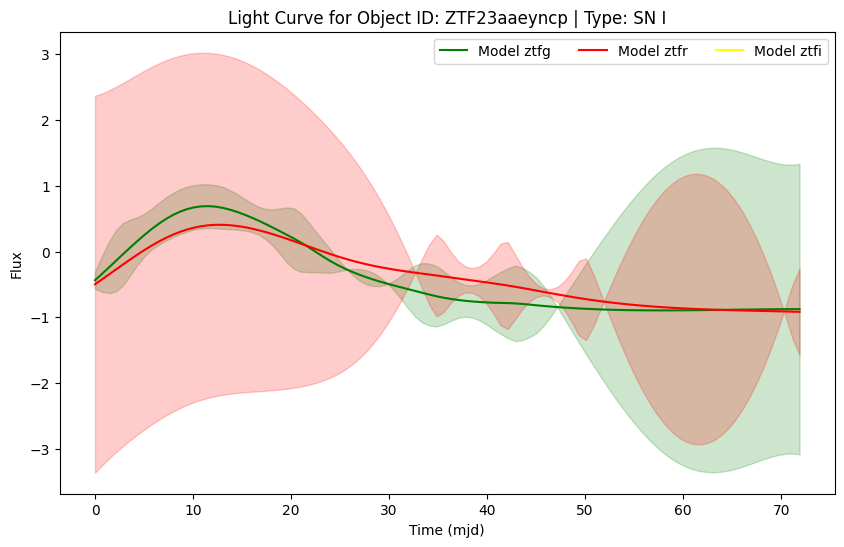

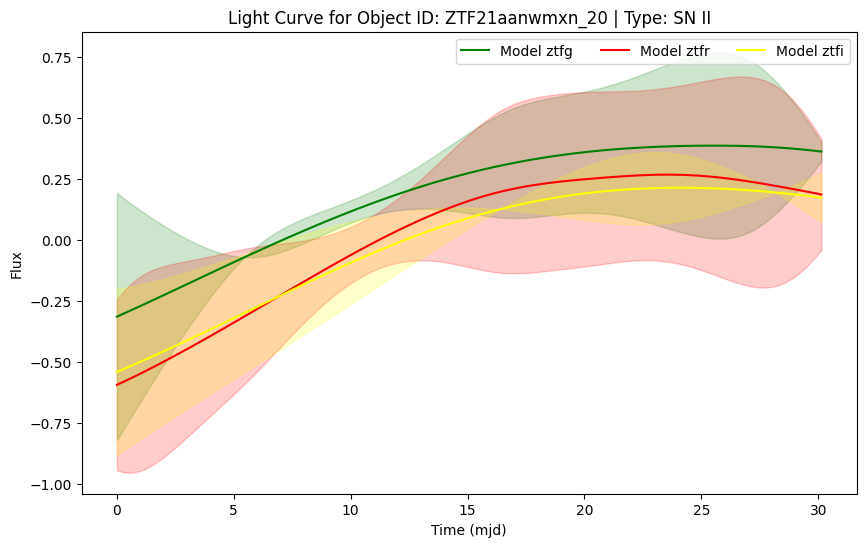

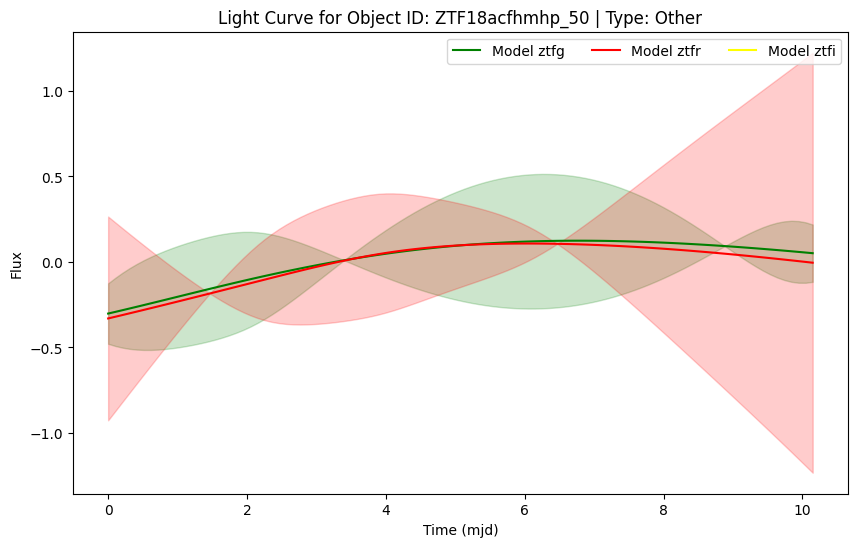

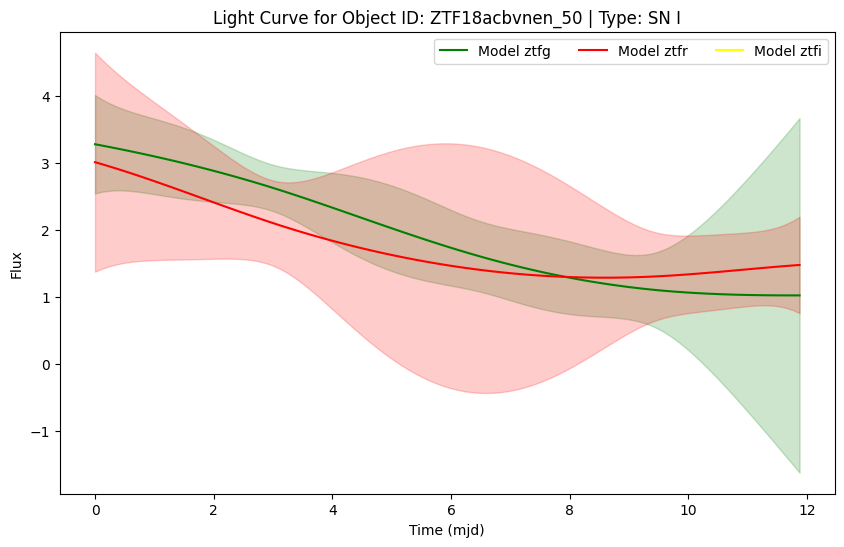

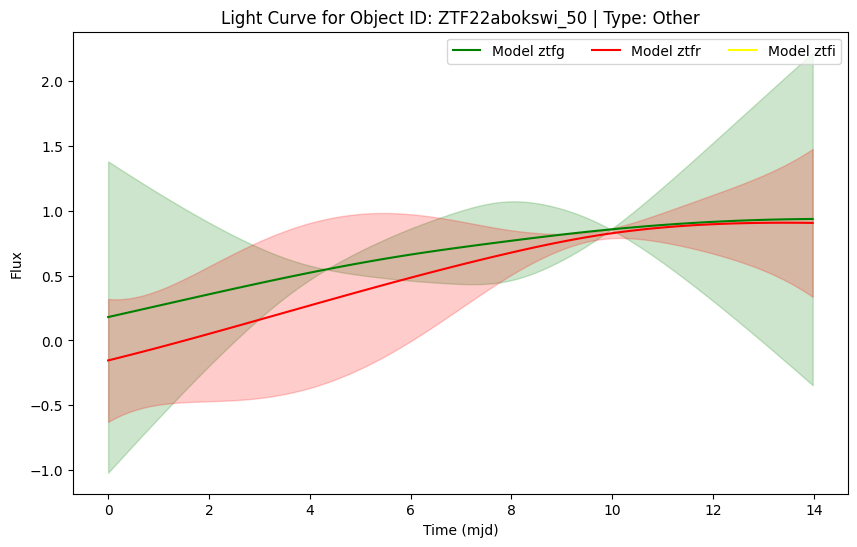

In [201]:
obj_ids = all_gp['obj_id'].unique()
for i in range(5):
    id_1 = random.choice(obj_ids)
    one_df = all_gp[all_gp['obj_id'] == id_1]
    plot_gp(one_df)

### Handling Missing Data in Filters

Many objects in our dataset exhibit zero recorded observations for one or more filters, resulting in numerous NaN (Not a Number) values. This absence of data can distort the analysis and model training process.

To ensure the integrity and effectiveness of our models, we preemptively remove any instances with NaN values from our dataset before proceeding with data preparation for modeling.

In [202]:
all_gp.dropna(inplace=True)
all_gp.reset_index(inplace=True)

### Data Augmentation Techniques

To enhance the robustness and generalization ability of our models, we employ several data augmentation techniques. Each method manipulates the data slightly differently to simulate various scenarios or introduce subtle variations that help the model learn more general features.

In [204]:
augmented_df = balanced_augmentation(all_gp)
augmented_df.to_csv('data/augmented_gp_Other_SN_I_SN_II.csv', index=False)

Augmenting Other 3 times:   0%|          | 0/4495 [00:00<?, ?it/s]


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [175]:
augmented_df = pd.read_csv('data/augmented_gp_Other_SN_I_SN_II.csv')
count_obj_by_type(all_gp)
count_obj_by_type(augmented_df)

type
Other    4495
SN I     8902
SN II    2906
Name: obj_id, dtype: int64
type
Other    17980
SN I     17804
SN II    14530
Name: obj_id, dtype: int64


#### Techniques Overview:

In [205]:
def window_warp(df, window_ratio=0.2, scale=2.5):
    columns_to_warp = ['flux_ztfg', 'flux_ztfr', 'flux_ztfi']
    for col in columns_to_warp:
        series = df[col]
        n = len(series)
        window_len = int(window_ratio * n)
        if window_len == 0:
            continue
        
        start = np.random.randint(0, n - window_len)
        end = start + window_len
        stretched_len = int(window_len * scale)
        new_end = min(start + stretched_len, n)
        
        stretched_window = np.interp(
            np.linspace(0, n-1, num=n),
            np.linspace(start, end, num=window_len),
            series[start:end]
        )
        
        df[col] = stretched_window
    return df

from scipy.interpolate import CubicSpline

def magnitude_warp(df, num_knots=4, sigma=0.4):
    columns = [col for col in df.columns if 'flux' in col]
    for col in columns:
        series = df[col]
        n = len(series)
        time_points = np.linspace(0, n-1, num=n)
        warp_points = np.linspace(0, n-1, num=num_knots)
        warp_values = np.random.normal(loc=1.0, scale=sigma, size=num_knots)
        spline = CubicSpline(warp_points, warp_values)
        warp_factor = spline(time_points)
        df[col] = series * warp_factor
    return df

def shuffle_flux_features(df):
    filters = ['ztfg', 'ztfr', 'ztfi']
    shuffled_filters = np.random.permutation(filters)
    
    for original, shuffled in zip(filters, shuffled_filters):
        df[f'flux_{original}'], df[f'flux_error_{original}'] = df[f'flux_{shuffled}'], df[f'flux_error_{shuffled}']
    
    return df

def add_gaussian_noise(df, variance=0.02):
    columns = [col for col in df.columns if 'flux' in col]
    for col in columns:
        noise = np.random.normal(0, np.sqrt(variance), df[col].shape)
        df[col] += noise
    return df

def augment_single_object(obj_df, augmentation_func, func_name):
    """
    Applies an augmentation function to a DataFrame containing a single time series object and modifies obj_id to include the function name.
    
    Parameters:
    - obj_df (DataFrame): DataFrame containing the data for a single object.
    - augmentation_func (callable): Function that applies the transformation.
    - func_name (str): Name of the augmentation function, used to modify obj_id.
    
    Returns:
    - DataFrame: The augmented DataFrame for the single object with updated obj_id.
    """
    augmented_obj = obj_df.copy()
    augmented_obj = augmentation_func(augmented_obj)  # Apply the augmentation directly to the DataFrame
    augmented_obj['obj_id'] = augmented_obj['obj_id'].apply(lambda x: x + '_' + func_name)
    return augmented_obj

In [ ]:
one_obj = all_gp[all_gp['obj_id'] == 'ZTF22aaptzap']
aug = augment_single_object(one_obj, window_warp, 'window_warp')

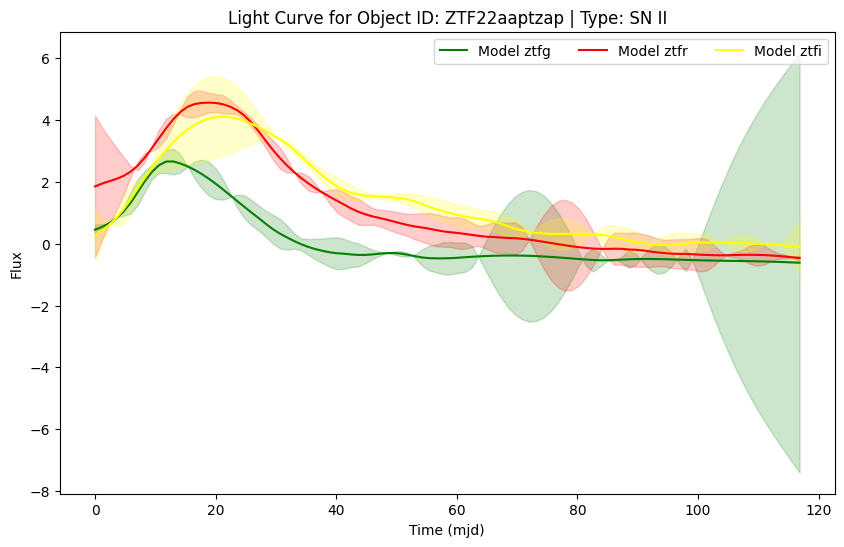

In [191]:
sn_ii_ids = augmented_df[augmented_df['type'] == 'SN II']['obj_id'].unique()
sn_ii_id = random.choice(sn_ii_ids)
sn_ii_id = 'ZTF22aaptzap'
plot_gp(augmented_df[augmented_df['obj_id'] == sn_ii_id])

1. **Window Warp**:
   - **Purpose**: Modifies a segment of the data series by stretching or compressing it.
   - **Implementation**: Selects a window of the series, stretches it by a factor, and interpolates to fit the series length.

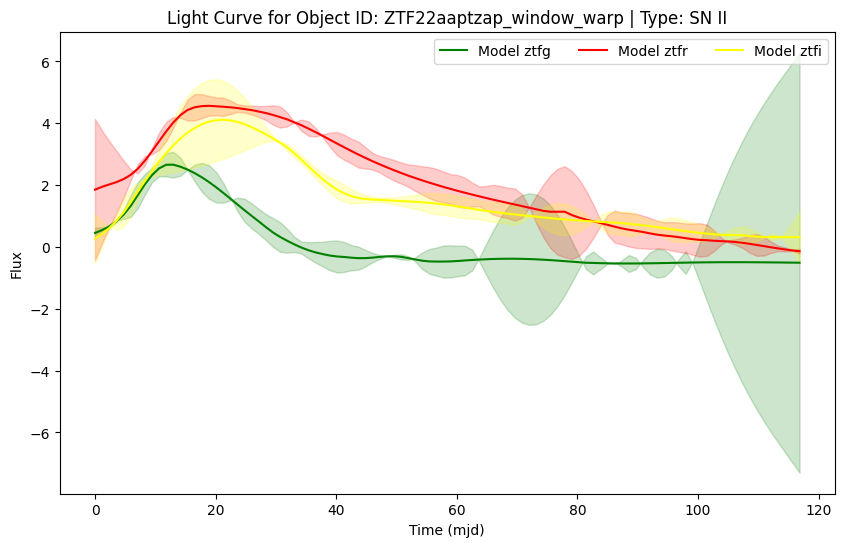

In [192]:
plot_gp(augmented_df[augmented_df['obj_id'] == sn_ii_id + '_window_warp'])

2. **Magnitude Warp**:
   - **Purpose**: Alters the magnitude of the data series to simulate changes in intensity.
   - **Implementation**: Uses cubic spline interpolation to smoothly vary the series magnitudes based on randomly generated control points.

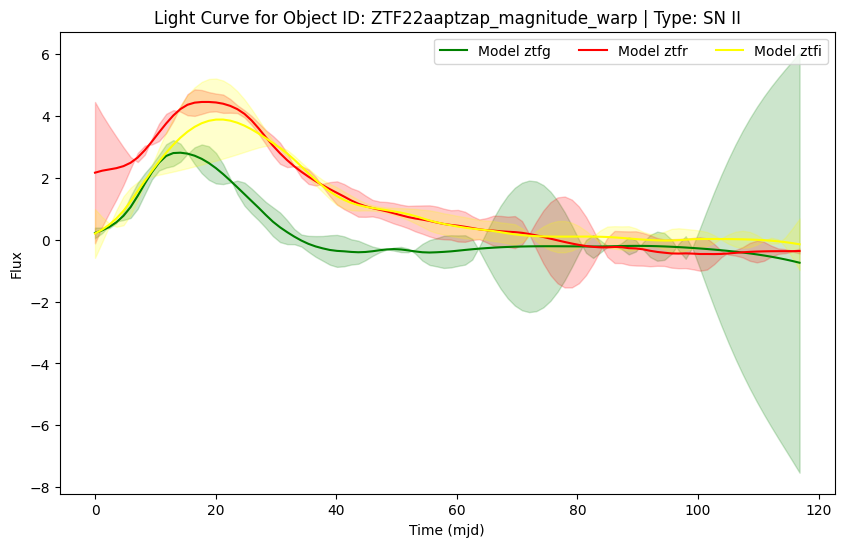

In [193]:
plot_gp(augmented_df[augmented_df['obj_id'] == sn_ii_id + '_magnitude_warp'])

3. **Shuffle Features**:
   - **Purpose**: Shuffles the order of features to test the model's dependency on the sequence of input features.
   - **Implementation**: Randomly shuffles the series along the feature dimension, preserving the temporal sequence.

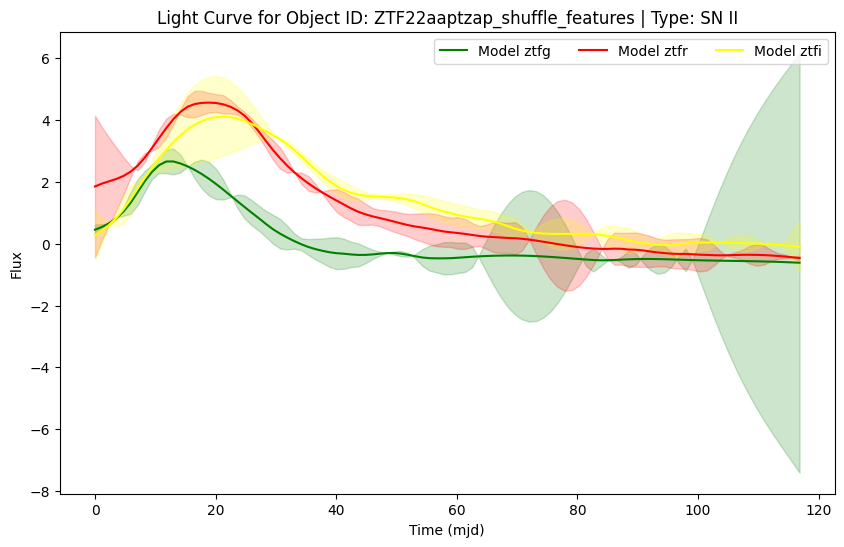

In [194]:
plot_gp(augmented_df[augmented_df['obj_id'] == sn_ii_id + '_shuffle_features'])

4. **Add Gaussian Noise**:
   - **Purpose**: Introduces random noise to the data series to mimic observational noise.
   - **Implementation**: Adds Gaussian noise to each point in the series, simulating real-world data collection imperfections.

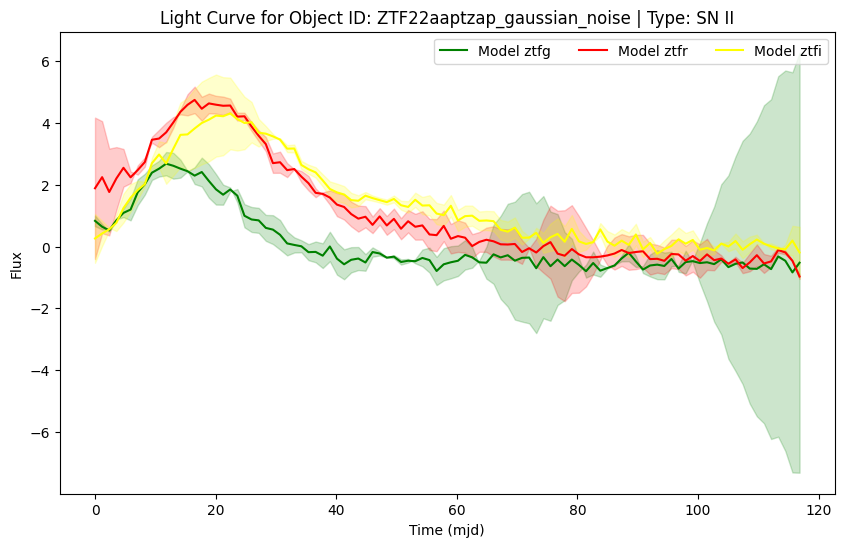

In [196]:
plot_gp(augmented_df[augmented_df['obj_id'] == sn_ii_id + '_gaussian_noise'])

## Data Preparation for Modeling

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import pad_sequences

grouped = df.groupby('obj_id')
sequences = [group[['mjd', 'flux_ztfg', 'flux_ztfi', 'flux_ztfr']].values for _, group in grouped]

types = df[['obj_id', 'type']].drop_duplicates().sort_values('obj_id')['type']
encoder = OneHotEncoder(sparse_output=False)
encoded_labels = encoder.fit_transform(types.values.reshape(-1, 1))
label_names = encoder.categories_[0]

padded_sequences = pad_sequences(sequences, padding='post', dtype='float32')

X_train, X_test, y_train, y_test = train_test_split(padded_sequences, encoded_labels, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Label names:", label_names)

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(label_names, y_train.sum(axis=0))
plt.title('Distribution of labels in the training set')
plt.show()

In [ ]:
print("NaN in X_train:", np.isnan(X_train).any())
print("Inf in X_train:", np.isinf(X_train).any())

## Class weight

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

y_train_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_integers), y=y_train_integers)
class_weight_dict = {i : class_weights[i] for i in range(len(class_weights))}

class_weight_dict

## T2 Model

![](assets/t2_model.png)

In [ ]:
sequence_length = X_train.shape[1]
feature_dim = X_train.shape[2]
num_classes = y_train.shape[1]

print("Sequence length:", sequence_length)
print("Feature dimension:", feature_dim)
print("Number of classes:", num_classes)

In [ ]:
from tensorflow.keras.optimizers import Adam
import src.models.T2_model as T2_model
importlib(T2_model)

from src.models.T2_model import T2Model

num_filters = 64
num_layers = 1
d_model = 64
num_heads = 16
dff = 128
rate = 0.2

model = T2Model(num_filters=num_filters, num_classes=num_classes, num_layers=num_layers,
                d_model=d_model, num_heads=num_heads, dff=dff, input_shape=(sequence_length, feature_dim), rate=rate)

model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

model.build(input_shape=(sequence_length, feature_dim))
model.summary()

## Callbacks

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
filepath = "best_model.keras"

callbacks_list = [
    EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20),
    ModelCheckpoint(filepath, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=8, mode='min', verbose=1),
]

# Training

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    shuffle=True,
    callbacks=callbacks_list,
    class_weight=class_weight_dict)

In [ ]:
plot_history(history)

# Evaluation on Test data

model.load_weights('/kaggle/working/best_model.keras')

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Loss: {loss:.3f}, Test Accuracy: {accuracy:.3f}')

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=label_names))

In [ ]:
plot_multi_class_roc(y_test, y_pred, label_names)

In [ ]:
plot_confusion_matrix(y_true, y_pred_classes, label_names)

In [ ]:
plot_class_accuracy(y_true, y_pred_classes, label_names)

In [ ]:
early_classification_tradeoff(model, X_test, y_test)

## Test with your own data

In [ ]:
def test_your_data(path):
    # check if path is a directory call load_photometry else read_csv
    df = pd.DataFrame()

    if os.path.isdir(path):
        # get all the name of all folder in path
        list_objs = os.listdir(path)
        df = load_all_photometry(list_obj, df)
    elif path.endwith('.csv'):
        df = pd.read_csv(path)
    else:
        print()
        return

    